# Práctica 3 - Ejercicio 1

Asignatura: Programación para la Inteligencia Artificial

Alumno: Fernández Roldán, Daniel

Típicamente el Aprendizjae Profundo se utiliza en problemas supervisados (conocemos la entrada y la salida para los datos de entrenamiento, validación y test). Este planteamiento tiene el problema de requerir que los datos hayan sido previamente etiquetados. Sin embargo, hay modelos neuronales que no tienen esta restricción.

Un Autocodificador (*Autoencoder*) es una red neuronal que se entrena para aprender la función identidad. Típicamente se puede dividir en dos secciones simétricas: una primera parte que codifica progresivamente la entrada a un espacio de menos dimensiones (denominado espacio latente) y una segunda parte que decodifica de vuelta al espacio de dimensiones original.

$x = d_{\theta_{1}}(e_{\theta_{2}}(x))$

Como aprende la función identidad, no requiere etiquetado para su entrenamiento.

Un Autocodificador con eliminación de ruido (*Denoising Autoencoder*) es una red neuronal que se entrena para eliminar el ruido de unos datos de entrada.

$x = d_{\theta_{1}}(e_{\theta_{2}}(\hat{x}))$

El objetivo de esta práctica es definir y entrenar un Autocodificar con eliminación de ruido capaz de lidiar con ruido gaussiano de media $\mu=0$ y desviación típica $\sigma=0.2$ para el conjunto de datos Fashion-MNIST (https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html). El autocodificador debe componerse de neuronas lineales y el espacio latente debe ser de 8 dimensiones.

Para evaluar la efectividad del modelo entrenado se deben utilizar todos los ejemplos del conjunto de test y el error absoluto. Se recomienda incluir el código necesario para mostrar un ejemplo cualquiera del conjunto de test con ruido, sin ruido y el resultado del autocodificador.

Una vez entrenado, se debe mostrar la relación entre las componentes de las codificaciones del conjunto de test con la clase asociada a dichas codificaciones. Se recomienda hacer gráficas 2D cuyos ejes muestren los valores de 2 componentes y muestren la clase como el color de cada punto.

El cuaderno entregado debe llamarse ApellidosNombrePractica3Ejercicio1.ipynb

Ej1: Autoencoder que quite el ruido (test error abs)
Ej2: Autoencoder que genere imágenes nuevas

In [7]:
# Import libraries.
import torch
import torch.nn.functional as F
import torchvision.datasets as datasets
import torchvision.transforms as transforms

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

from tqdm import tqdm

import matplotlib.pyplot as plt

In [8]:
# Define the transform to convert images to tensors.
transform = transforms.ToTensor()


# Load the Fashion-MNIST dataset.
train_images = datasets.FashionMNIST(root='data', train=True, download=True, transform=transform)
test_images = datasets.FashionMNIST(root='data', train=False, download=True, transform=transform)

# Split the training dataset into training and validation datasets.
train_size = int(0.8 * len(train_images))
val_size = len(train_images) - train_size

# Define the training, validation, and test datasets.
train_dataset, val_dataset = random_split(train_images, [train_size, val_size])
test_dataset = test_images

# Define the data loaders for training, validation, and testing.
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

In [9]:
def add_noise(image, deviation=0.2):
    """
    Function to add noise to the images in the dataset. 
    The noise is generated from a normal distribution with mean 0 and standard deviation 0.2. 
    The noisy images are clipped to be in the range [0, 1].
    """
    # Generate noise from a normal distribution with mean 0 and standard deviation 0.2.
    noise = torch.randn_like(image) * deviation

    # Add the noise to the image and clip the values to be in the range [0, 1].
    noisy_image = image + noise

    # Clip the values to be in the range [0, 1].
    final_image = torch.clamp(noisy_image, min=0., max=1.)

    return final_image

In [10]:
class Autoencoder(nn.Module):
    """
    Autoencoder class that defines the architecture of the autoencoder model.
    """
    def __init__(self):
        super(Autoencoder, self).__init__()
        # Define the encoder part of the autoencoder.
        self.encoder = nn.Sequential(
            nn.Flatten(),  # Flatten the input image to a vector.
            nn.Linear(28 * 28, 128),  # Fully connected layer with 128 neurons.
            nn.ReLU(),  # ReLU activation function.
            nn.Linear(128, 64),  # Fully connected layer with 64 neurons.
            nn.ReLU(),  # ReLU activation function.
            nn.Linear(64, 8),  # Fully connected layer with 8 neurons.
        )

        self.decoder = nn.Sequential(
            nn.Linear(8, 64),  # Fully connected layer with 64 neurons.
            nn.ReLU(),  # ReLU activation function.
            nn.Linear(64, 128),  # Fully connected layer with 128 neurons.
            nn.ReLU(),  # ReLU activation function.
            nn.Linear(128, 28 * 28),  # Fully connected layer with 28*28 neurons (to reconstruct the image).
            nn.Sigmoid()  # Sigmoid activation function to ensure the output is in the range [0, 1].
        )

    def forward(self, x):
        """
        Forward pass of the autoencoder.
        """
        # Compress the input image to a lower-dimensional representation and then reconstruct it back to the original image.
        encoded_image = self.encoder(x)  # Pass the input through the encoder.
        # Reconstruct the image from the encoded representation.
        reconstructed_image = self.decoder(encoded_image)  # Pass the encoded representation through the decoder.

        return reconstructed_image.view(-1, 1, 28, 28)  # Return the reconstructed image in its original shape (28x28).

In [11]:
# Define the training loop for the autoencoder model.
def learning_loop(model, train_loader, val_loader, loss_fn, optimizer, device, num_epochs=10):
    """
        Function to train the autoencoder model. It takes the model, training and validation data loaders, loss function, optimizer, device (CPU or GPU), and number of epochs as input. It trains the model for the specified number of epochs and returns the training and validation losses.
    """
    # Initialize lists to store the training and validation losses.
    train_historial_loss = []
    val_historial_loss = []

    for epoch in range(num_epochs):
        model.train()  # Set the model to training mode.
        train_loss_accumulated = 0.0  # Initialize the training loss for the current epoch.

        # Use tqdm to create a progress bar for the training loop.
        loop_train = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

        for images, _ in loop_train:
            images = images.to(device)  # Move the images to the specified device (CPU or GPU).

            noisy_images = add_noise(images)  # Add noise to the images.

            predicted_images = model(noisy_images)  # Pass the noisy images through the autoencoder to get the reconstructed images.
            optimizer.zero_grad()  # Zero the gradients of the optimizer.
            loss_train = loss_fn(predicted_images, images)  # Calculate the loss between the predicted and original images.
            loss_train.backward()  # Backpropagate the loss to compute gradients.
            optimizer.step()  # Update the model parameters using the optimizer.

            train_loss_accumulated += loss_train.item() * images.size(0)  # Accumulate the training loss for the current epoch.
            loop_train.set_postfix(loss=loss_train.item())

        train_loss_media = train_loss_accumulated / len(train_loader.dataset)  # Calculate the average training loss for the current epoch.
        train_historial_loss.append(train_loss_media)

        model.eval()  # Set the model to evaluation mode.
        val_loss_accumulated = 0.0  # Initialize the validation loss for the current epoch.
        # Use tqdm to create a progress bar for the validation loop.
        val_loop = tqdm(val_loader, desc=f"Validation {epoch+1}/{num_epochs}")

        with torch.no_grad():  # Disable gradient calculation for validation.
            for images, _ in val_loop:
                images = images.to(device)  # Move the images to the specified device (CPU or GPU).

                noisy_images = add_noise(images)  # Add noise to the images.

                predicted_images = model(noisy_images)  # Pass the noisy images through the autoencoder to get the reconstructed images.
                loss_val = loss_fn(predicted_images, images)  # Calculate the loss between the predicted and original images.

                val_loss_accumulated += loss_val.item() * images.size(0)  # Accumulate the validation loss for the current epoch.
                val_loop.set_postfix(loss=loss_val.item())

        val_loss_media = val_loss_accumulated / len(val_loader.dataset)  # Calculate the average validation loss for the current epoch.
        val_historial_loss.append(val_loss_media)

        print(f"Epoch [{epoch + 1}/{num_epochs}], Train Loss: {train_loss_media:.4f}, Val Loss: {val_loss_media:.4f}")

    # Return the trained model and the training and validation loss histories.
    return model, train_historial_loss, val_historial_loss

In [12]:
# Define the device to use for training (GPU if available, otherwise CPU).
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entrenando en: {device}")

model = Autoencoder().to(device)  # Create an instance of the autoencoder model and move it to the specified device.

loss_fn = nn.L1Loss() # Define the loss function as L1 loss (mean absolute error).

optimizer = optim.Adam(model.parameters(), lr=0.001)  # Define the optimizer as Adam with a learning rate of 0.001.

num_epochs = 10  # Define the number of epochs to train the model.

# Train the autoencoder model using the learning loop function.
model, train_historial_loss, val_historial_loss = learning_loop(
    model, 
    train_loader,
    val_loader, 
    loss_fn,
    optimizer, 
    device, num_epochs)



Entrenando en: cuda


Epoch 1/10:   0%|          | 0/750 [00:00<?, ?it/s]

Validation 1/10: 100%|██████████| 188/188 [00:04<00:00, 45.10it/s, loss=0.0954] 


Epoch [1/10], Train Loss: 0.1356, Val Loss: 0.0957


Validation 2/10: 100%|██████████| 188/188 [00:04<00:00, 45.56it/s, loss=0.0875] 


...

Epoch [8/10], Train Loss: 0.0703, Val Loss: 0.0703


Validation 9/10: 100%|██████████| 188/188 [00:04<00:00, 42.77it/s, loss=0.0718] 


Epoch [9/10], Train Loss: 0.0691, Val Loss: 0.0688


Validation 10/10: 100%|██████████| 188/188 [00:04<00:00, 42.16it/s, loss=0.0713] 

Epoch [10/10], Train Loss: 0.0678, Val Loss: 0.0685


Final Absolute Error (Test): 0.0685


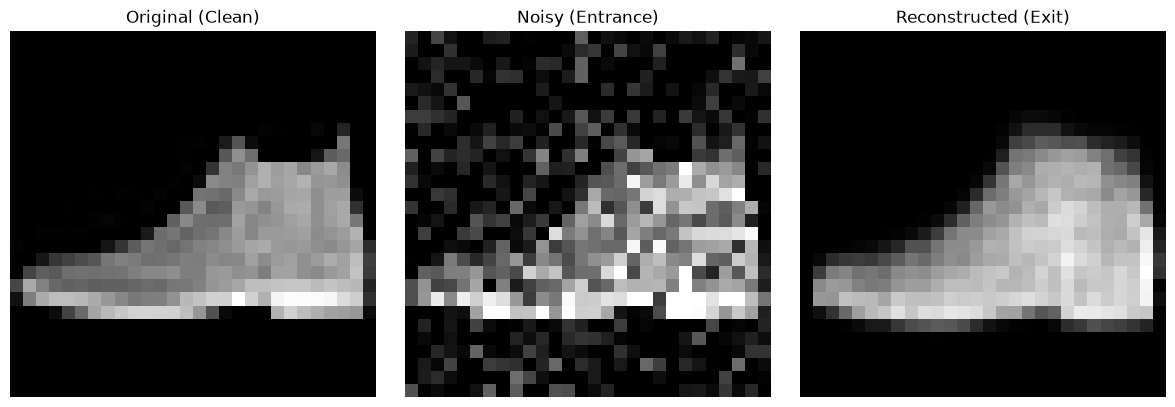

In [13]:
# Testing phase and graph the results of the trained autoencoder model.
model.eval() # Set the model to evaluation mode.
test_loss_accumulated = 0.0 # Initialize the test loss for the testing phase.

with torch.no_grad(): # Disable gradient calculation for testing.
    for images, _ in test_loader: # Iterate over the test dataset in batches.
        images = images.to(device) # Move the images to the specified device (CPU or GPU).
        noisy_images = add_noise(images) # Add noise to the images.
        predicted_images = model(noisy_images) # Pass the noisy images through the autoencoder to get the reconstructed images.
        
        loss_test = loss_fn(predicted_images, images) # Calculate the loss between the predicted and original images.
        test_loss_accumulated += loss_test.item() * images.size(0) # Accumulate the test loss for the current batch.

# Calculate the average test loss over the entire test dataset.
absolute_error_test = test_loss_accumulated / len(test_loader.dataset)
print(f"Final Absolute Error (Test): {absolute_error_test:.4f}")

# Results Visualization: Displaying the original, noisy, and reconstructed images for comparison.
#Extract a single batch of test images and keep only the first one.
test_images, _ = next(iter(test_loader))
test_images = test_images.to(device)

# Select the first image while maintaining its dimensional structure (1, 1, 28, 28)
original_image = test_images[0:1] 

# A. Apply the noise function to this 'original_image'.
noisy_image = add_noise(original_image)

# B. Use the trained model to clean the noisy image.
with torch.no_grad():
    reconstructed_image = model(noisy_image)

# Prepare the tensors for Matplotlib (move them to CPU, remove extra dimensions, and convert to NumPy)
img_orig_plot = original_image.cpu().squeeze().numpy()
img_noisy_plot = noisy_image.cpu().squeeze().numpy()
img_recon_plot = reconstructed_image.cpu().squeeze().numpy()

# Dibujamos la comparativa
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Original (Clean)")
plt.imshow(img_orig_plot, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Noisy (Entrance)")
plt.imshow(img_noisy_plot, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Reconstructed (Exit)")
plt.imshow(img_recon_plot, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

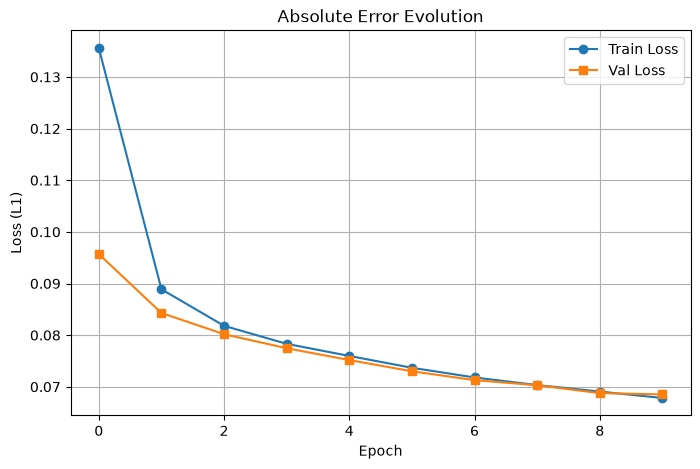

In [14]:
plt.figure(figsize=(8, 5))
# Plot the training loss
plt.plot(train_historial_loss, label='Train Loss', marker='o')
# Plot the validation loss
plt.plot(val_historial_loss, label='Val Loss', marker='s')

plt.title('Absolute Error Evolution')
plt.xlabel('Epoch')
plt.ylabel('Loss (L1)')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
# 1. Prepare lists to store information for the entire test dataset
latent_encodings = []
real_labels = []

model.eval()
with torch.no_grad():
    # Iterate over the test_loader. Here we DO save the labels
    for images, labels in test_loader:
        images = images.to(device)
        
        # KEY STEP: We do not call model(images). 
        # We ONLY call the first half (the block you defined in your __init__)
        latent_space = model.encoder(images)
        
        # Save this batch in our lists (move to CPU for matplotlib)
        latent_encodings.append(latent_space.cpu())
        real_labels.append(labels)

# 2. Concatenate all small batches into a single large tensor
all_encodings = torch.cat(latent_encodings)
all_labels = torch.cat(real_labels)

print("Shape of the encodings:", all_encodings.shape)

Shape of the encodings: torch.Size([10000, 8])
